In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("SampleSuperstore.csv")

## 1 Understand Dataset

In [4]:
df.head()

,csvbase_row_id,﻿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
1,3,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
2,5,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
3,6,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
4,7,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8827 entries, 0 to 8826
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   csvbase_row_id  8827 non-null   int64  
 1   ﻿Row ID         8827 non-null   int64  
 2   Order ID        8827 non-null   str    
 3   Order Date      8827 non-null   str    
 4   Ship Date       8827 non-null   str    
 5   Ship Mode       8827 non-null   str    
 6   Customer ID     8827 non-null   str    
 7   Customer Name   8827 non-null   str    
 8   Segment         8827 non-null   str    
 9   Country         8827 non-null   str    
 10  City            8827 non-null   str    
 11  State           8827 non-null   str    
 12  Postal Code     8827 non-null   int64  
 13  Region          8827 non-null   str    
 14  Product ID      8827 non-null   str    
 15  Category        8827 non-null   str    
 16  Sub-Category    8827 non-null   str    
 17  Product Name    8827 non-null   str    
 18 

In [6]:
df.describe()


,csvbase_row_id,﻿Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,8827.000000,8827.000000,8827.000000,8827.000000,8827.000000,8827.000000,8827.000000
mean,5016.375892,5016.375892,55373.635663,92.864853,3.608587,0.157606,11.198644
std,2888.406540,2888.406540,31974.536840,114.045078,2.129308,0.211531,49.066101
min,1.000000,1.000000,1040.000000,0.444000,1.000000,0.000000,-1181.282400
25%,2508.500000,2508.500000,23320.000000,15.008000,2.000000,0.000000,1.702400
50%,5028.000000,5028.000000,59801.000000,40.880000,3.000000,0.200000,7.437600
75%,7517.500000,7517.500000,90008.000000,124.225000,5.000000,0.200000,21.335400
max,9994.000000,9994.000000,99301.000000,498.260000,14.000000,0.800000,240.859500


In [7]:
df.shape

(8827, 22)

In [8]:
df.columns

Index(['csvbase_row_id', '﻿Row ID', 'Order ID', 'Order Date', 'Ship Date',
       'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country',
       'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

## 2 Data Clening

In [9]:
df.isnull().sum()

csvbase_row_id    0
﻿Row ID           0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [12]:
Q1=df["Sales"].quantile(0.25)
Q3=df["Sales"].quantile(0.75)

IQR=Q3-Q1

df=df[(df["Sales"]>=Q1-1.5*IQR) &
      (df["Sales"]<=Q3+1.5*IQR)]

In [13]:
df.to_csv("Sample-Superstore.csv",index=False)

## 3 EDA Visualizations

(array([3623., 1488.,  821.,  550.,  360.,  311.,  276.,  215.,  219.,
         178.]),
 array([  0.444 ,  29.1996,  57.9552,  86.7108, 115.4664, 144.222 ,
        172.9776, 201.7332, 230.4888, 259.2444, 288.    ]),
 <BarContainer object of 10 artists>)

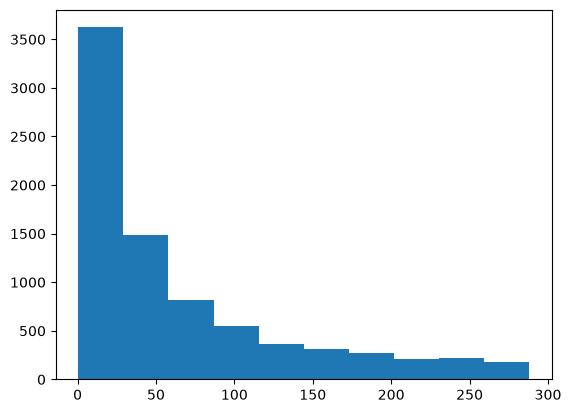

In [14]:
plt.hist(df["Sales"])

<Axes: ylabel='Sales'>

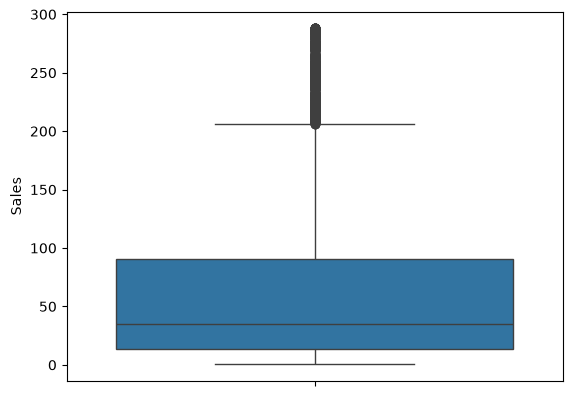

In [15]:
sns.boxplot(df["Sales"])

<Axes: xlabel='Category', ylabel='count'>

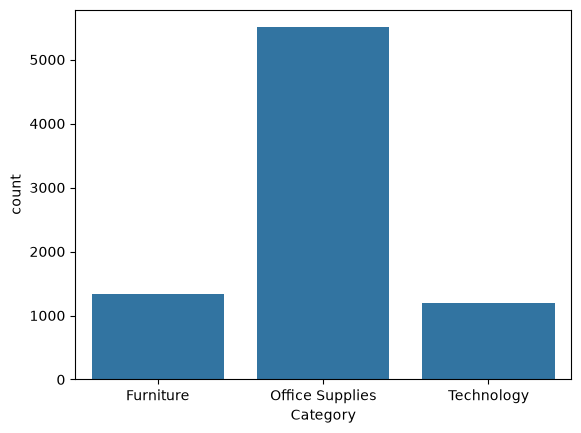

In [16]:
sns.countplot(x="Category",data=df)

<Axes: >

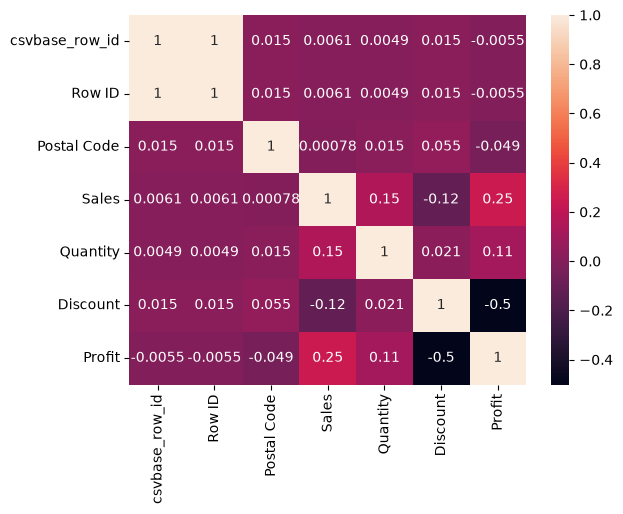

In [17]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Order Date'>

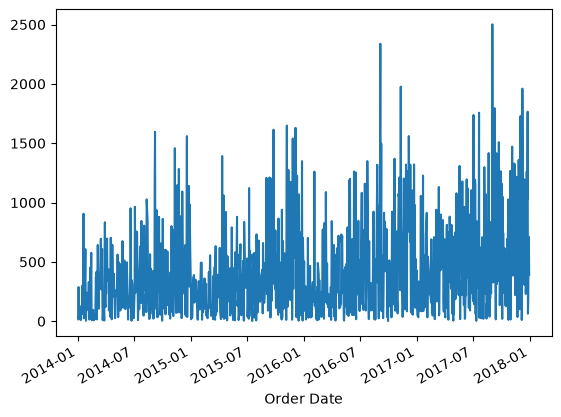

In [18]:
sales=df.groupby("Order Date")["Sales"].sum()

sales.plot()

## Key Insights

1. Technology category has highest sales.

2. West region generated highest revenue.

3. Furniture has lower profit.

4. November has maximum sales.

5. Discount negatively affects profit.

In [19]:
!pip install pyodbc sqlalchemy


[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from sqlalchemy import create_engine
import urllib

# Your SQL Server details
server = r"RAUNAK-KUMAR\SQLEXPRESS"   # Use raw string for backslash
database = "SuperstoreDB"            # Your database name
driver = "ODBC Driver 17 for SQL Server"   # Must be installed on your machine

# Build connection string for Windows Authentication
connection_string = urllib.parse.quote_plus(
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

# Create engine
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={connection_string}")

print("✔ Successfully connected to SQL Server (Windows Authentication)!")

✔ Successfully connected to SQL Server (Windows Authentication)!


In [22]:
table_name = "SampleSuperstore"   # SQL table name you want to create

df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"✔ Data successfully loaded into table '{table_name}' in database 'SuperstoreDB'.")

✔ Data successfully loaded into table 'SampleSuperstore' in database 'SuperstoreDB'.


In [24]:
import pandas as pd

df = pd.read_csv("SampleSuperstore.csv")

df.to_sql(
    "Orders",
    engine,
    if_exists="replace",
    index=False
)

print("Data Imported Successfully!")

Data Imported Successfully!


In [25]:
query = "SELECT TOP 10 * FROM Orders"

df = pd.read_sql(query, engine)

print(df)

   csvbase_row_id  ﻿Row ID        Order ID  Order Date   Ship Date  \
0               1        1  CA-2016-152156  2016-11-08  2016-11-11   
1               3        3  CA-2016-138688  2016-06-12  2016-06-16   
2               5        5  US-2015-108966  2015-10-11  2015-10-18   
3               6        6  CA-2014-115812  2014-06-09  2014-06-14   
4               7        7  CA-2014-115812  2014-06-09  2014-06-14   
5               9        9  CA-2014-115812  2014-06-09  2014-06-14   
6              10       10  CA-2014-115812  2014-06-09  2014-06-14   
7              13       13  CA-2017-114412  2017-04-15  2017-04-20   
8              14       14  CA-2016-161389  2016-12-05  2016-12-10   
9              15       15  US-2015-118983  2015-11-22  2015-11-26   

        Ship Mode Customer ID    Customer Name      Segment        Country  \
0    Second Class    CG-12520      Claire Gute     Consumer  United States   
1    Second Class    DV-13045  Darrin Van Huff    Corporate  United State

In [26]:
query = """
SELECT Category,
SUM(Sales) AS TotalSales
FROM Orders
GROUP BY Category
"""

result = pd.read_sql(query, engine)

print(result)

          Category   TotalSales
0  Office Supplies  343425.0040
1        Furniture  247877.6984
2       Technology  228415.3530


In [28]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine("sqlite:///superstore.db")

query = """
SELECT Category,
SUM(Sales) AS TotalSales
FROM Orders
GROUP BY Category
"""

result = pd.read_sql(query, engine)

print(result)

          Category   TotalSales
0        Furniture  247877.6984
1  Office Supplies  343425.0040
2       Technology  228415.3530


## Answer Business Questions

### Examples

Top 10 Products

Monthly Sales

Region Wise Sales

Top Customers

Average Profit

Highest Discount

Lowest Sales Month

Category Revenue

State Wise Sales

Customer Segmentation